Importing dependencies and loading the dataset

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
import xgboost as xgb
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials
from hyperopt.pyll.base import scope
import tqdm
import eli5
from eli5.sklearn import PermutationImportance
import warnings
warnings.filterwarnings("ignore")

%matplotlib inline

# Path of the file to read.
data_path = "countries-aggregated_csv.csv"
# Reading the file
data = pd.read_csv(data_path )

Making target y and input X for the XGBRegressor model and then splitting X and y into validation and training data.

In [3]:
# Create target object and call it y
y = data.Deaths

# Create X
features = ['Confirmed', 'Recovered']
X = data[features]

# Split into validation and training data
train_X, val_X, train_y, val_y = train_test_split(X, y, test_size=0.3, random_state=1)

Search space for hyperparameters.

In [32]:
# Define the search space
space = {
    'n_estimators': scope.int(hp.quniform('n_estimators', 100, 1000, 1)),
    'learning_rate': hp.uniform('learning_rate', 0.01, 0.3),
    'max_depth': scope.int(hp.quniform('max_depth', 3, 18, 1)),
    'min_child_weight': hp.quniform('min_child_weight', 0, 10, 1),
    'gamma': hp.uniform('gamma', 1, 9),
    "reg_alpha": hp.uniform("reg_alpha", 0, 1),
    "reg_lambda": hp.uniform("reg_lambda", 0, 1),
    "random_state": 1,
    "seed": 0,
    "max_bin": scope.int(hp.quniform("max_bin", 100, 1000, 1)),
}

Method that trains the model with the given parameters and calculates the MAE score and returns loss, status of the model.


In [22]:
def get_params(space):
    # Inputing the parameters
    model = xgb.XGBRegressor(**space)
    
    # Evaluation set
    eval_set = [(train_X, train_y), (val_X, val_y)]

    # Fit the model on the eval_set with early stopping
    model.fit(train_X, train_y, eval_set=eval_set, eval_metric="mae", early_stopping_rounds=50, verbose=False)

    # Get model predictions
    pred = model.predict(val_X)

    # Calculate MAE
    mae = mean_absolute_error(val_y, pred)
    print(f"MAE: {mae}")

    return {'loss': mae, 'status': STATUS_OK, 'model': model}

Bayesian optimization algorithm to find the most optimized parameters for the model.

In [33]:
trials = Trials()

best_params = fmin(fn=get_params,
                   space=space,
                   algo=tpe.suggest,
                   max_evals=100,
                   trials=trials)

MAE: 3211.4973840619023                                
MAE: 3050.2481646910724                                                          
MAE: 3320.2048888334484                                                          
MAE: 3174.274240754773                                                           
MAE: 3199.7681657302096                                                          
MAE: 3051.3062446243243                                                          
MAE: 3088.314322352069                                                           
MAE: 3204.6117173132907                                                          
MAE: 3834.004781673503                                                           
MAE: 3086.8731370390337                                                          
MAE: 3125.4997278259834                                                           
MAE: 3078.9156384460443                                                           
MAE: 3089.791158462538                  

Inputing the algorithm results to define the XGBRegressor model.

In [34]:
xgb_best_model = trials.best_trial['result']['model']
print("The best hyperparameters are:")
print(best_params)
print("\nThe best optimized model:")
print(xgb_best_model)

The best hyperparameters are:
{'gamma': 6.885342311511158, 'learning_rate': 0.023345464749578035, 'max_bin': 353.0, 'max_depth': 17.0, 'min_child_weight': 6.0, 'n_estimators': 928.0, 'reg_alpha': 0.5555309523729582, 'reg_lambda': 0.7712989329445546}

The best optimized model:
XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=6.885342311511158, gpu_id=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.023345464749578035, max_bin=353,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=17, max_leaves=None,
             min_child_weight=6.0, missing=nan, monotone_constraints=None,
             n_estimators=928, n_jobs=None, num_parallel_tree=Non

Testing how much better the optimized model is compared to the standard model.

In [35]:
# Testing the best model with the validation data
xgb_best_model.fit(train_X, train_y, eval_set=[(train_X, train_y), (val_X, val_y)], eval_metric=["mae"], early_stopping_rounds=50, verbose=False)
xgb_best_model_pred = xgb_best_model.predict(val_X)
xgb_best_model_mae = mean_absolute_error(val_y, xgb_best_model_pred)
print(f"MAE_Best_Model: {xgb_best_model_mae}")

# Testing the standard model with the validation data
xgb_standart_model = xgb.XGBRegressor()
xgb_standart_model.fit(train_X, train_y, eval_set=[(train_X, train_y), (val_X, val_y)], eval_metric=["mae"], early_stopping_rounds=50, verbose=False)
xgb_standart_model_pred = xgb_standart_model.predict(val_X)
xgb_standart_model_mae = mean_absolute_error(val_y, xgb_standart_model_pred)
print(f"MAE_Standard_Model: {xgb_standart_model_mae}")
print(f"MAE_Difference: {xgb_standart_model_mae - xgb_best_model_mae}")

MAE_Best_Model: 3041.990608466916
MAE_Standard_Model: 3252.5959268569372
MAE_Difference: 210.60531839002124


Checking what features are important for the model.

In [36]:
# Using permutation importance to see which features are the most important for the model
perm = PermutationImportance(xgb_best_model, random_state=1).fit(val_X, val_y)
eli5.show_weights(perm, feature_names = val_X.columns.tolist())

Weight,Feature
1.8785 ± 0.0132,Confirmed
0.0786 ± 0.0041,Recovered


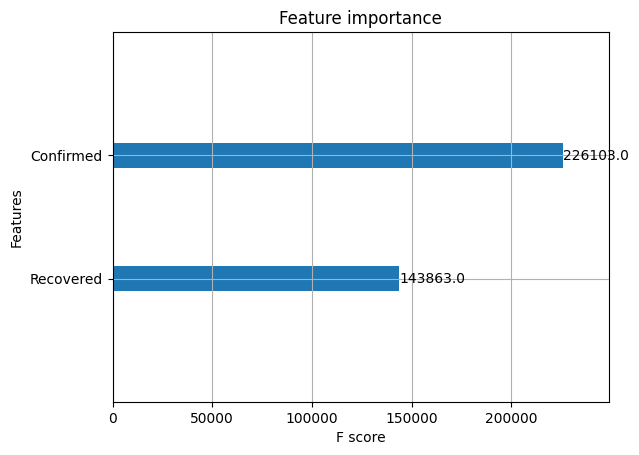

In [37]:
# Plotting the feature importance
xgb.plot_importance(xgb_best_model)
plt.show()

Plotting the variance between the actual and the predicted deaths with simple linear regression to see visually model performance.

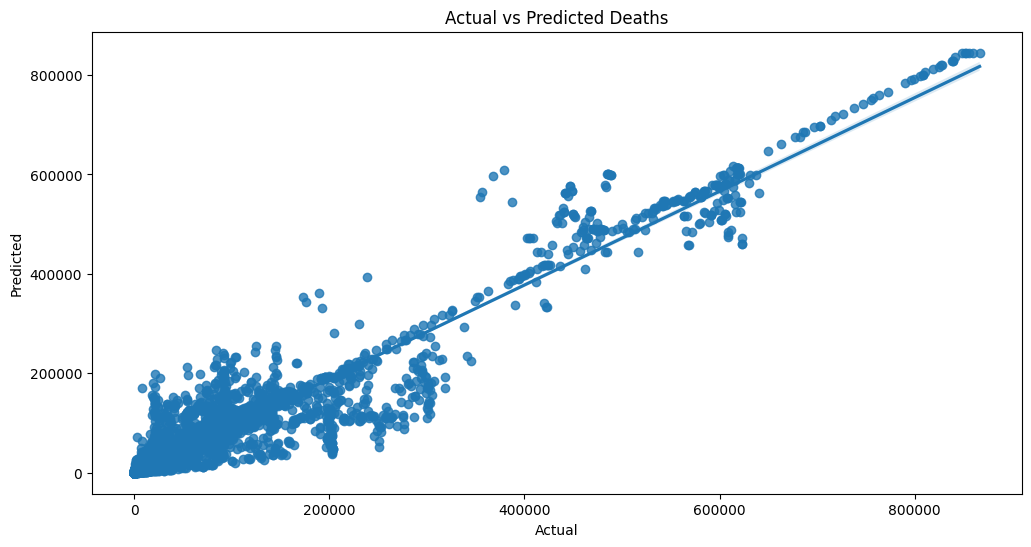

In [38]:
# Making dataframe to show variance between the actual and predicted values
df = pd.DataFrame({'Actual': val_y, 'Predicted': xgb_best_model_pred})
plt.figure(figsize=(12,6))
sns.regplot(x="Actual", y="Predicted", data=df) # Order=1
plt.title("Actual vs Predicted Deaths")
plt.show()